In [2]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import random_split
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import copy
from tqdm import trange, tqdm

In [19]:
class PlantVillage(Dataset):
    def __init__(self, root, transforms=None):
        super().__init__()
        self.root = Path(root)
        self.transforms = transforms
        self.classes = sorted(c.name for c in self.root.iterdir() if c.is_dir())
        self.IDXclasses = {cls:idx for idx,cls in enumerate(self.classes)}
        self.images = []
        for cls in self.classes:
            class_path = self.root / cls
            for f in sorted(class_path.iterdir()):
                if f.suffix.lower() ==".jpg":
                    self.images.append((f, self.IDXclasses[cls]))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transforms:
            image = self.transforms(image)
        return image, label

In [20]:
full_data = PlantVillage("PlantVillage")
n = full_data.__len__()
n_train = int(0.7*n)
n_val = int(0.15*n)
n_test = n-n_train-n_val
train_subset, val_subset, test_subset = random_split(
    full_data, 
    [n_train, n_val, n_test],
    generator = torch.Generator().manual_seed(123)
)

In [21]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(0.15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor()
    ])
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [22]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        super().__init__()
        self.subset = subset
        self.transform =transform
        self.classes = sorted(c.name for c in Path("PlantVillage").iterdir() if c.is_dir())
        self.IDXclasses = {cls:idx for idx,cls in enumerate(self.classes)}
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [23]:
train_data = TransformSubset(train_subset, transform=train_transforms)
val_data = TransformSubset(val_subset, transform=test_transforms)
test_data = TransformSubset(test_subset, transform=test_transforms)

In [24]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [25]:
def show_image(data, idx):
    tensor = data[idx][0]
    label = data.classes[data[idx][1]]
    img = tensor.permute(1,2,0).numpy()
    img = np.clip(img, 0,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label)
    plt.show()

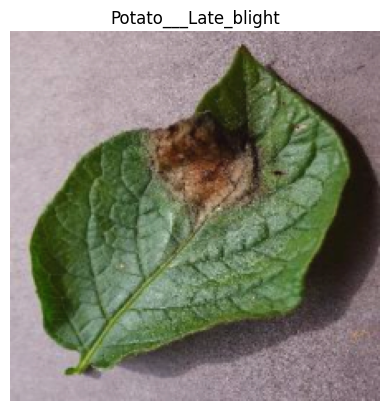

In [26]:
show_image(train_data, 10000)

In [27]:
im, lbl = next(iter(train_loader))
print(im.shape)
im, lbl = next(iter(val_loader))
print(im.shape)
im, lbl = next(iter(test_loader))
print(im.shape)

torch.Size([128, 3, 224, 224])
torch.Size([128, 3, 224, 224])
torch.Size([128, 3, 224, 224])


In [28]:
#From scratch model
class Block(nn.Module):
    expansion=1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels,out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels,  kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        if self.downsample is not None:
            identity=self.downsample(x)

        out +=identity
        out = self.relu(out)
        return out
        

In [29]:
class ResNet18Scratch(nn.Module):
    def __init__(self, num_classes=15):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3,64,kernel_size=7, stride=2, padding=3,bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu=nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._makeLayer(64,2,stride=1)
        self.layer2 = self._makeLayer(128, 2, stride=2)
        self.layer3 = self._makeLayer(256, 2, stride=2)
        self.layer4 = self._makeLayer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512* Block.expansion, num_classes)

        self._init_weights("")

    def _makeLayer(self, out_channels, num_blocks, stride):
        downsample=None
        if stride !=1 or self.in_channels!=out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        layers = [Block(self.in_channels, out_channels, stride=stride, downsample=downsample)]
        self.in_channels=out_channels
        for _ in range(1,num_blocks):
            layers.append(Block(out_channels,out_channels))
        return nn.Sequential(*layers)
    def _init_weights(self,_):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    def forward(self, x):
        x= self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x=self.layer1(x)
        x=self.layer2(x)
        x=self.layer3(x)
        x=self.layer4(x)
        x=self.avgpool(x)
        x=torch.flatten(x, 1)
        x= self.fc(x)
        return x

In [30]:
model = ResNet18Scratch()
crit = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=75)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
crit=crit.to(device)

In [31]:
def train_one(model, loader, crit, optimizer, device):
    model.train()
    running_loss, running_corrects = 0.0,0
    for inputs, labels in tqdm(loader, desc="Training", leave=False) :
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = crit(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs,1)
        running_loss+= loss.item()*inputs.size(0)
        running_corrects += (preds==labels).sum().item()
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_corrects/len(loader.dataset)
    return epoch_loss, epoch_acc

In [32]:
@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval()
    running_loss, running_corrects = 0.0,0
    for inputs, labels in tqdm(loader, desc="Evaluation", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = crit(outputs, labels)
        _, preds = torch.max(outputs, 1)
        running_loss+=loss.item()*inputs.size(0)
        running_corrects += (preds==labels).sum().item()
    epoch_loss = running_loss/len(loader.dataset)
    epoch_acc = running_corrects/len(loader.dataset)
    return epoch_loss, epoch_acc

In [ ]:
def train_model(model, dataloaders, crit, optimizer, scheduler, num_epochs, device):
    best_weights = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history      = {"train_loss": [], "train_acc": [],
                    "val_loss":   [], "val_acc":   []}
    model.to(device)
    for epoch in trange(num_epochs):
        t_loss, t_acc = train_one(model, dataloaders["train"], crit, optimizer, device)
        v_loss, v_acc = evaluate(model,dataloaders["val"], crit, device)
        scheduler.step()
        history["train_loss"].append(t_loss)
        history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        print(f"Epoch {epoch+1:3d}/{num_epochs} |"f"Train loss: {t_loss:.4f}  Acc: {t_acc*100:.2f}"f"Val Loss: {v_loss:0.4f}  Acc: {v_acc*100:0.2f}")
        if v_acc>best_acc:
            best_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), "best_model.pth")
    return model, history

In [34]:
train_model(model, {"train":train_loader, "val":val_loader}, crit, optimizer, scheduler, 75, device)

  1%|▏         | 1/75 [02:59<3:41:59, 179.99s/it]

Epoch   1/75 |Train loss: 1.2339  Acc: 59.59Val Loss: 4.0576  Acc: 23.33


  3%|▎         | 2/75 [04:56<2:53:37, 142.71s/it]

Epoch   2/75 |Train loss: 0.6438  Acc: 78.19Val Loss: 5.3488  Acc: 27.69


  4%|▍         | 3/75 [06:52<2:36:49, 130.69s/it]

...

 99%|█████████▊| 74/75 [2:30:03<01:57, 117.94s/it]

Epoch  74/75 |Train loss: 0.0002  Acc: 100.00Val Loss: 0.0231  Acc: 99.32


100%|██████████| 75/75 [2:32:01<00:00, 121.62s/it]

Epoch  75/75 |Train loss: 0.0002  Acc: 100.00Val Loss: 0.0233  Acc: 99.35


(ResNet18Scratch(
   (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
   (layer1): Sequential(
     (0): Block(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
     (1): Block(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(

In [1]:
@torch.no_grad()
def test_model(model, loader, class_names, device=device):
    model.eval()
    
    correct = 0
    total   = 0
    class_correct = [0] * len(class_names)
    class_total   = [0] * len(class_names)

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        for label, pred in zip(labels, preds):
            if label == pred:
                class_correct[label.item()] += 1
            class_total[label.item()] += 1

    # ── Overall ──
    overall_acc = 100 * correct / total
    print(f"\n{'='*45}")
    print(f"  Overall Accuracy: {overall_acc:.2f}%  ({correct}/{total})")
    print(f"{'='*45}")

    # ── Per-class ──
    print(f"\n{'Class':<45} {'Correct':>8} {'Total':>8} {'Acc':>8}")
    print("-" * 72)
    for i, name in enumerate(class_names):
        if class_total[i] == 0:
            continue
        acc = 100 * class_correct[i] / class_total[i]
        print(f"{name:<45} {class_correct[i]:>8} {class_total[i]:>8} {acc:>7.2f}%")

    return overall_acc

NameError: name 'torch' is not defined

In [ ]:
test_model(model, test_loader, test_data.classes, device)


  Overall Accuracy: 99.16%  (3070/3096)

Class                                          Correct    Total      Acc
------------------------------------------------------------------------
Pepper__bell___Bacterial_spot                      158      158  100.00%
Pepper__bell___healthy                             218      219   99.54%
Potato___Early_blight                              139      139  100.00%
Potato___Late_blight                               158      160   98.75%
Potato___healthy                                    21       22   95.45%
Tomato_Bacterial_spot                              342      344   99.42%
Tomato_Early_blight                                164      172   95.35%
Tomato_Late_blight                                 293      296   98.99%
Tomato_Leaf_Mold                                   142      144   98.61%
Tomato_Septoria_leaf_spot                          264      265   99.62%
Tomato_Spider_mites_Two_spotted_spider_mite        234      235   99.57%
Tomato__T

99.16020671834626

: 